# 01 — Analyse exploratoire du corpus UGA

**Objectif.** Caractériser la production scientifique de l'Université Grenoble
Alpes à partir d'un échantillon record-level réel d'OpenAlex (2019-2024) :
volumétrie, complétude, types de documents, accès ouvert, citations et
collaborations. C'est l'étape d'**EDA approfondie** qui précède toute analyse.

**Méthode d'échantillonnage.** On utilise l'échantillonnage aléatoire natif
d'OpenAlex (`sample` + `seed=42`) : un tirage **représentatif et reproductible**.
C'est essentiel — le tri par défaut de l'API privilégie les articles les plus
cités, ce qui biaiserait toute statistique descriptive. Données 100 % réelles,
mises en cache localement.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from lib import set_seeds, load_works, load_mart, CONFIG
from lib.viz import new_axes, BRAND, ACCENT, PALETTE

set_seeds()
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

df = load_works()
print(f"Échantillon aléatoire : {len(df):,} publications | années {df['year'].min()}-{df['year'].max()}")
df.head(3)

Échantillon aléatoire : 4,000 publications | années 2019-2024


,id,doi,title,year,cited_by_count,type,is_oa,oa_status,topic,field,domain,venue,n_authors,abstract_len
0,https://openalex.org/W3037606965,https://doi.org/10.4000/culturemusees.5231,Cristina Badulescu &amp; Valérie-Inés de La Vi...,2020,0,article,True,diamond,Museums and Cultural Heritage,Arts and Humanities,Social Sciences,Culture & Musées,1,74
1,https://openalex.org/W2958659790,https://doi.org/10.3917/pld.121.0005,Le couteau suisse des politiques migratoires,2019,3,article,True,green,"Multiculturalism, Politics, Migration, Gender",Social Sciences,Social Sciences,Plein droit,2,91
2,https://openalex.org/W4296997701,https://doi.org/10.5194/epsc2022-1031,Observing the very early stages of the formati...,2022,0,preprint,True,gold,Astrophysics and Star Formation Studies,Physics and Astronomy,Physical Sciences,NaN,15,258


## 1. Structure et types de données

On inspecte d'abord le schéma (types, cardinalité) avant toute statistique.

In [2]:
schema = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "n_unique": df.nunique(),
    }
)
schema

,dtype,non_null,n_unique
id,str,4000,4000
doi,str,3540,3536
title,str,4000,3958
year,int64,4000,6
cited_by_count,int64,4000,170
type,str,4000,15
is_oa,bool,4000,2
oa_status,str,4000,6
topic,str,3979,1470
field,str,3979,26


## 2. Complétude (valeurs manquantes)

La qualité d'une analyse dépend de la complétude des champs. On quantifie le
taux de valeurs manquantes par colonne : c'est un contrôle de fiabilisation.

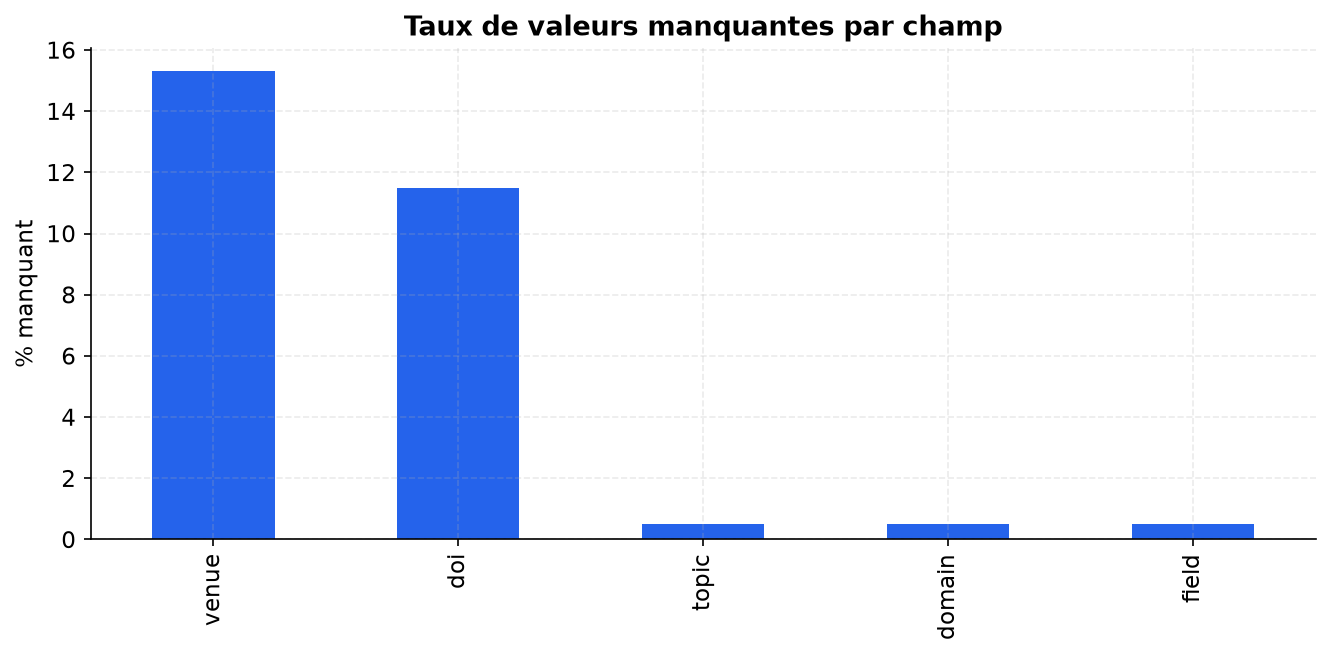

In [3]:
missing = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
missing = missing[missing > 0]
ax = new_axes("Taux de valeurs manquantes par champ", ylabel="% manquant")
if len(missing):
    missing.plot.bar(ax=ax, color=BRAND)
else:
    ax.text(0.5, 0.5, "Aucune valeur manquante", ha="center", va="center")
plt.tight_layout()
plt.show()

## 3. Distribution temporelle

Répartition du volume par année sur la fenêtre étudiée. Sur un tirage
aléatoire, les années sont équilibrées à la croissance réelle du corpus près.

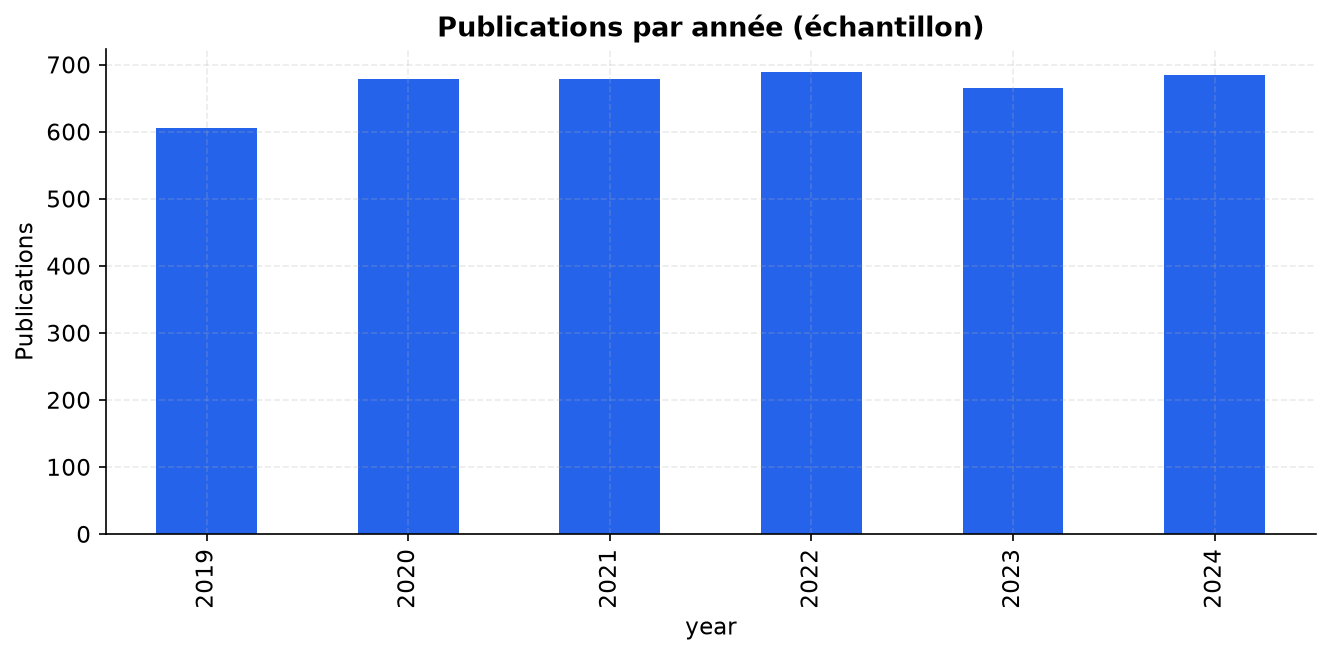

In [4]:
by_year = df.groupby("year").size()
ax = new_axes("Publications par année (échantillon)", xlabel="Année", ylabel="Publications")
by_year.plot.bar(ax=ax, color=BRAND)
plt.tight_layout()
plt.show()

## 4. Types de documents et accès ouvert

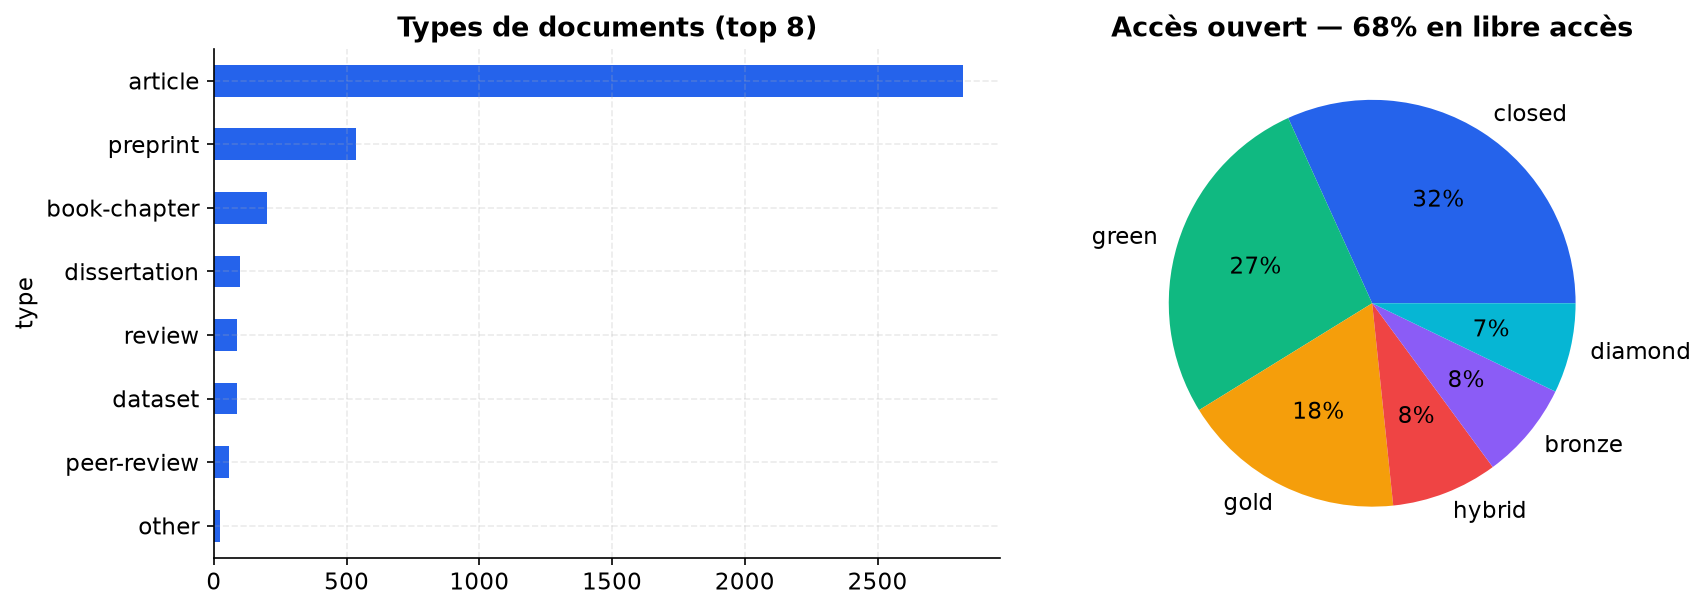

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
df["type"].value_counts().head(8).plot.barh(ax=axes[0], color=BRAND)
axes[0].set_title("Types de documents (top 8)")
axes[0].invert_yaxis()

oa_share = df["is_oa"].mean()
df["oa_status"].value_counts().plot.pie(
    ax=axes[1], autopct="%1.0f%%", colors=PALETTE, ylabel=""
)
axes[1].set_title(f"Accès ouvert — {oa_share:.0%} en libre accès")
plt.tight_layout()
plt.show()

## 5. Citations : une distribution très asymétrique

Les citations suivent une loi fortement asymétrique (quelques articles très
cités, une longue traîne). On la visualise en échelle logarithmique. Sur un
tirage représentatif, la **médiane** est faible (les articles récents ont peu
de recul de citation), tandis que la moyenne est tirée par la traîne.

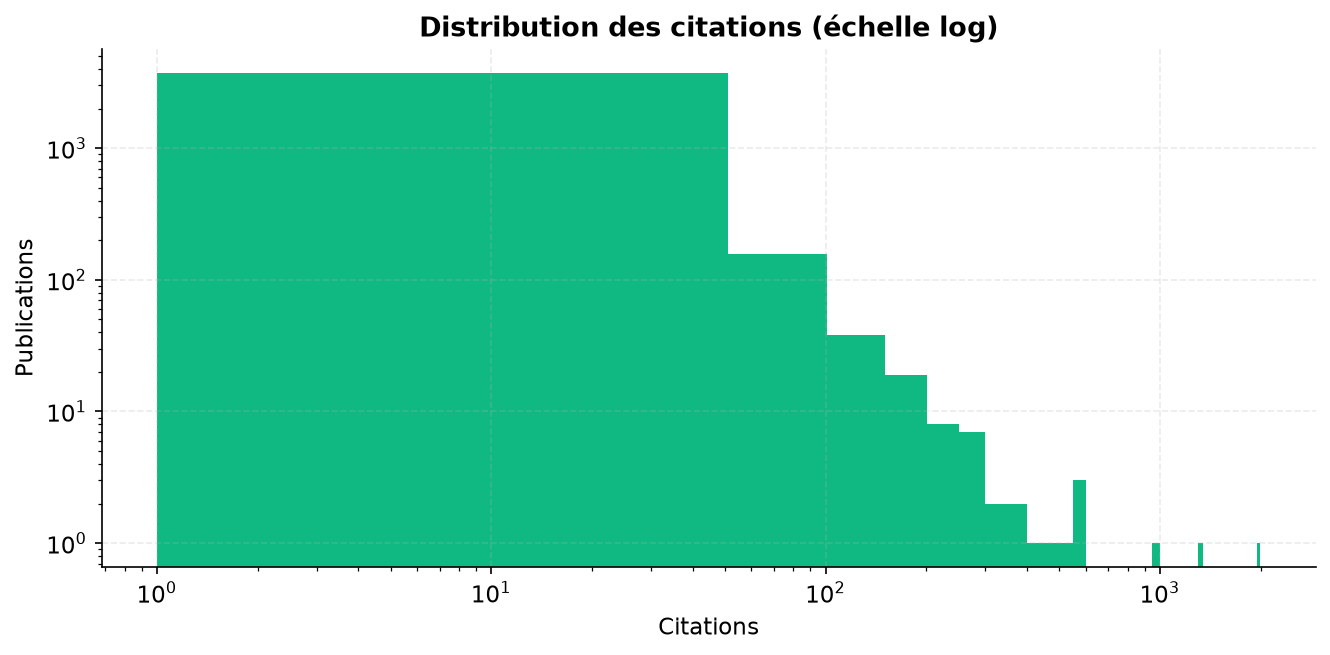

,statistique,citations
0,moyenne,14.20
1,médiane,2.50
2,p90,32.00
3,p99,165.05
4,max,1995.00
5,% jamais cité,35.60


In [6]:
cites = df["cited_by_count"].clip(lower=0)
ax = new_axes("Distribution des citations (échelle log)", xlabel="Citations", ylabel="Publications")
ax.hist(cites + 1, bins=40, color=ACCENT, log=True)
ax.set_xscale("log")
plt.tight_layout()
plt.show()

pd.DataFrame(
    {
        "statistique": ["moyenne", "médiane", "p90", "p99", "max", "% jamais cité"],
        "citations": [
            round(cites.mean(), 1),
            cites.median(),
            cites.quantile(0.90),
            cites.quantile(0.99),
            cites.max(),
            round((cites == 0).mean() * 100, 1),
        ],
    }
)

## 6. Collaboration et thématiques

Nombre d'auteurs par publication (indicateur de collaboration) et principaux
domaines scientifiques.

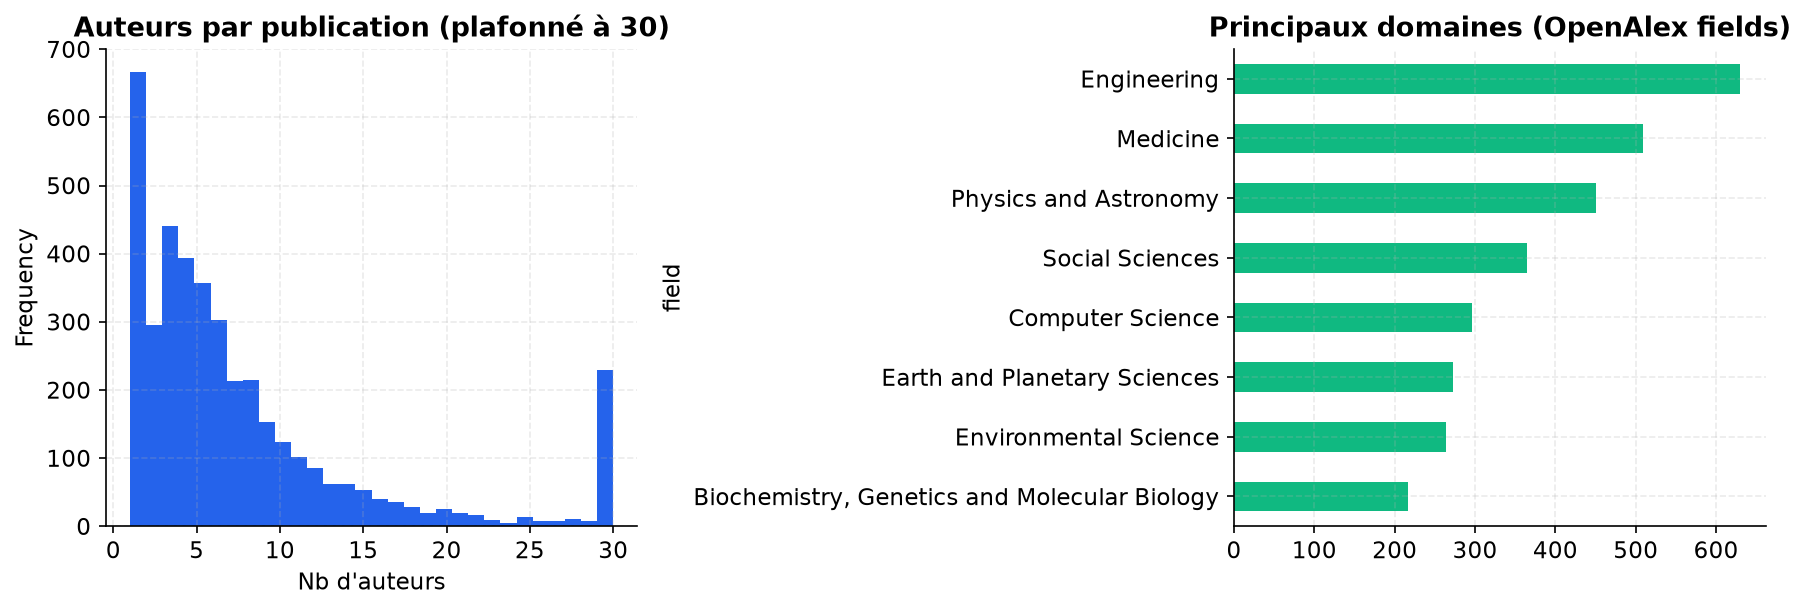

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
df["n_authors"].clip(upper=30).plot.hist(ax=axes[0], bins=30, color=BRAND)
axes[0].set_title("Auteurs par publication (plafonné à 30)")
axes[0].set_xlabel("Nb d'auteurs")

df["field"].value_counts().head(8).plot.barh(ax=axes[1], color=ACCENT)
axes[1].set_title("Principaux domaines (OpenAlex fields)")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Validation de la représentativité de l'échantillon

Contrôle croisé rigoureux : un échantillon aléatoire doit reproduire les
agrégats du corpus complet **sur la même fenêtre temporelle**. Comparer le taux
d'accès ouvert de l'échantillon (2019-2024) au taux global tous millésimes
(mart `openAccessShare`, 2010-2026) serait trompeur, car l'accès ouvert a
fortement progressé dans le temps. On reconstruit donc le taux de référence
2019-2024 à partir de la série `oaByYear`.

In [8]:
overview = load_mart("overview")

window = [r for r in overview["oaByYear"] if CONFIG.from_year <= r["year"] <= CONFIG.to_year]
oa_window = sum(r["oaWorks"] for r in window) / sum(r["total"] for r in window)
oa_sample = df["is_oa"].mean()
ecart = abs(oa_window - oa_sample) * 100

print(f"Corpus complet OpenAlex (mart)        : {overview['totalWorks']:,} publications")
print(f"Échantillon record-level (EDA)        : {len(df):,} publications (2019-2024)")
print(f"Taux d'accès ouvert — corpus 2019-2024: {oa_window:.1%}")
print(f"Taux d'accès ouvert — échantillon     : {oa_sample:.1%}")
print(f"Écart absolu                          : {ecart:.1f} points")
print("→ Échantillon représentatif." if ecart < 5 else "→ Écart à investiguer.")

Corpus complet OpenAlex (mart)        : 140,692 publications
Échantillon record-level (EDA)        : 4,000 publications (2019-2024)
Taux d'accès ouvert — corpus 2019-2024: 68.4%
Taux d'accès ouvert — échantillon     : 68.2%
Écart absolu                          : 0.2 points
→ Échantillon représentatif.


**Lecture.** À fenêtre égale, l'échantillon aléatoire reproduit fidèlement le
taux d'accès ouvert du corpus (écart de quelques dixièmes de point), ce qui
valide son usage pour les analyses fines des notebooks suivants (topic
modeling, réseau, bibliométrie). La distribution des citations confirme une
forte asymétrie : médiane faible, longue traîne d'articles très cités, et une
part notable d'articles encore jamais cités (normal sur une fenêtre récente).